In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os

session_name = "test4"
data_dir = '/tmp/vlmap_recording/' + session_name
depth_dir = data_dir + "/depth"
rgb_dir = data_dir + "/rgb"
pose_dir = data_dir + "/pose"

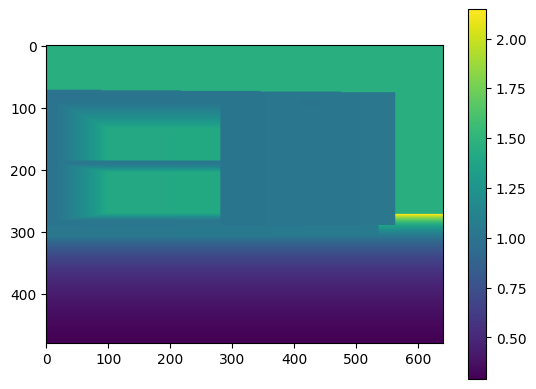

In [43]:
# get a test depth image and plot it
test_depth_img = np.load(os.path.join(depth_dir, f"{session_name}_000000.npy"))
plt.imshow(test_depth_img, cmap='viridis')
plt.colorbar()
plt.show()

In [44]:
# helper functions
from scipy.spatial.transform import Rotation as R
def load_pose(pose_filepath):
    with open(pose_filepath, "r") as f:
        line = f.readline()
        row = [float(x) for x in line.split()]
        pos = np.array(row[:3], dtype=float).reshape((3, 1))
        quat = row[3:]
        r = R.from_quat(quat)
        rot = r.as_matrix()
        return pos, rot

def transform_pc(pc, pose):
    """
    pose: the pose of the camera coordinate where the pc is in
    """
    pc_homo = np.vstack([pc, np.ones((1, pc.shape[1]))])

    pc_global_homo = pose @ pc_homo

    return pc_global_homo[:3, :]

In [45]:
# The camera intrinsic matrix
# obtained by echoing the /camera/camera_info topic in ROS
cam_mat = np.array([
    [528.43,   0.,   320.  ],
    [  0.,   528.43, 240.  ],
    [  0.,     0.,     1.  ]
])
cam_mat_inv = np.linalg.inv(cam_mat)

# Fixed rotation: camera optical → camera_link (standard ROS convention)
# optical:     x right,   y down,    z forward
# camera_link: x forward, y left,    z up
R_optical_to_link = np.array([
    [ 0,  0,  1],   # x_link  =  z_optical  (forward)
    [-1,  0,  0],   # y_link  = -x_optical  (left)
    [ 0, -1,  0],   # z_link  = -y_optical  (up)
])

# Gazebo world is z-up; Open3D can show z-up fine, but if you want
# Open3D's default "nice" view (y-up), apply this after world transform
R_world_to_open3d = np.array([
    [1,  0,  0],   # x stays x
    [0,  0,  1],   # y_o3d = z_world  (world z-up → Open3D y-up)
    [0, -1,  0],   # z_o3d = -y_world
])

h, w = test_depth_img.shape

y, x = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
x = x.reshape((1, -1))[:, :]
y = y.reshape((1, -1))[:, :]

point_clouds = []
pc_colors = []
depth_sample_rate = 200
tf_list = []
init_tf_inv = None

from utils.clip_mapping_utils import depth2pc_gazebo

# for i in range(10):
for i in range(len(os.listdir(pose_dir))):
    d = np.load(os.path.join(depth_dir, f"{session_name}_{i:06d}.npy"))
    rgb = plt.imread(os.path.join(rgb_dir, f"{session_name}_{i:06d}.png"))
    z = d.reshape((1, -1))

    pc_optical, mask = depth2pc_gazebo(d, cam_mat)   # shape (3, N), optical frame

    shuffle_mask = np.arange(pc_optical.shape[1])
    np.random.shuffle(shuffle_mask)
    shuffle_mask = shuffle_mask[::depth_sample_rate]

    mask        = mask[shuffle_mask]
    pc_optical  = pc_optical[:, shuffle_mask]
    pc_optical  = pc_optical[:, mask]

    # --- Step 1: optical → camera_link (fixed ROS rotation) ---
    pc_link = R_optical_to_link @ pc_optical

    # --- Step 2: camera_link → world (using pose from file) ---
    pos, rot = load_pose(os.path.join(pose_dir, f"{session_name}_{i:06d}.txt"))
    pose = np.eye(4)
    pose[:3, :3] = rot
    pose[:3, 3]  = pos.reshape(-1)
    

    pc_world = transform_pc(pc_link, pose)  # now in Gazebo world frame

    # --- Step 3: world → Open3D display convention (optional) ---
    # pc_viz = R_world_to_open3d @ pc_world
    pc_viz = pc_world

    rgb = rgb.reshape(-1, 3)[shuffle_mask][mask]
    pc_colors.append(rgb)
    point_clouds.append(pc_viz)

In [46]:
print(f"Total number of points: {sum([pc.shape[1] for pc in point_clouds])}")

pc_all = np.concatenate(point_clouds, axis=1)
# clip values of z < 0
# pc_all = pc_all[:, pc_all[2, :] >= 0]
pc_colors = np.concatenate(pc_colors, axis=0)

Total number of points: 173792


In [6]:
pc_all_v = pc_all
x_min, y_min, z_min = pc_all_v.min(axis=1)
x_max, y_max, z_max = pc_all_v.max(axis=1)
print(x_min, y_min, z_min)
print(x_max, y_max, z_max)

-3.342829613761336 -0.864636347627225 2.5217873048072326e-05
2.0545548268041744 3.482033666812372 1.9409810514455197


In [47]:
# plot point clouds using open3d
# plot all the point clouds together
import open3d as o3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pc_all[:3][:, :].T)
pcd.colors = o3d.utility.Vector3dVector(pc_colors)
o3d.visualization.draw_geometries([pcd])

In [52]:
# get a 2d occupancy grid from the 3d image
# pc_all_v = np.linalg.inv(R_world_to_open3d) @ pc_all
pc_all_v = pc_all
x_min, y_min, z_min = pc_all_v.min(axis=1)
x_max, y_max, z_max = pc_all_v.max(axis=1)
print(x_min, y_min, z_min)
print(x_max, y_max, z_max)
cs = 0.05
oc = np.ones((int((x_max - x_min)/cs), int((y_max - y_min)/cs)))
print(oc.shape)
for x,y,z in pc_all.T:
    if z < 0.1 or  z > 1.36:
        continue
    # if x< 0:
    #     continue
    # if y> 2.5:
    #     continue
    gx = int((x - x_min)/cs - 1)
    gy = int((y - y_min)/cs - 1)
    # print(x,y)
    oc[gx][gy] = 0

-3.378595624959212 -2.074740913082969 0.0032064599508102587
2.7901506229978006 3.6310532180419397 1.9444900378419352
(123, 114)


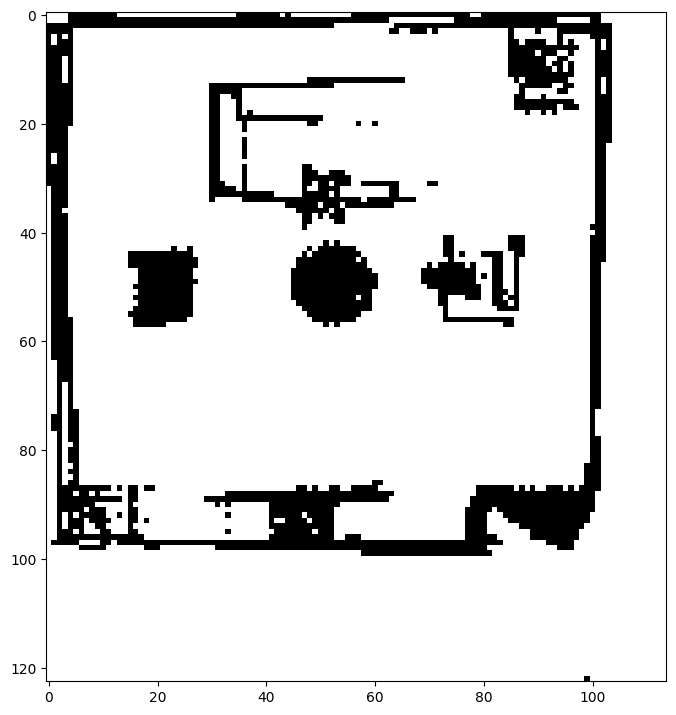

In [53]:
fig = plt.figure(figsize=(8, 10))
plt.imshow(oc, cmap='gray')